In [ ]:
# Import required libraries
import cv2                  # OpenCV for image processing
import numpy as np          # NumPy for numerical computations
import pandas as pd        # Pandas for data manipulation
import matplotlib.pyplot as plt    # Matplotlib for plotting
from matplotlib import rcParams   # For matplotlib settings

# Configure plot appearance settings
rcParams['font.family'] = 'serif'           # Use serif font family
rcParams['font.serif'] = ['Times New Roman'] # Set Times New Roman as the specific font

In [2]:
# Generate 100 x data points in the range [-5, 5]
x = np.linspace(-5, 5, 100)

# Create random noise for realistic data simulation
noise = np.random.normal(0, 5, size=x.shape)

# Generate y values using a cubic function with added noise
# Function: y = x³ - 2x² + x + noise
y = x**3 - 2*x**2 + x + noise

# Combine x and y into a pandas DataFrame for easier data handling
df = pd.DataFrame({"x": x, "y": y})

In [3]:
# Save DataFrame to a .txt file using tab as delimiter
df.to_csv("DATA/du_lieu.txt", sep="\t", index=False)

# Save DataFrame to a .csv file using comma as delimiter (default)
df.to_csv("DATA/du_lieu.csv", index=False)

In [4]:
# Read the tab-delimited .txt file
df_txt = pd.read_csv("DATA/du_lieu.txt", delimiter="\t")

# Read the comma-delimited .csv file
df_csv = pd.read_csv("DATA/du_lieu.csv")

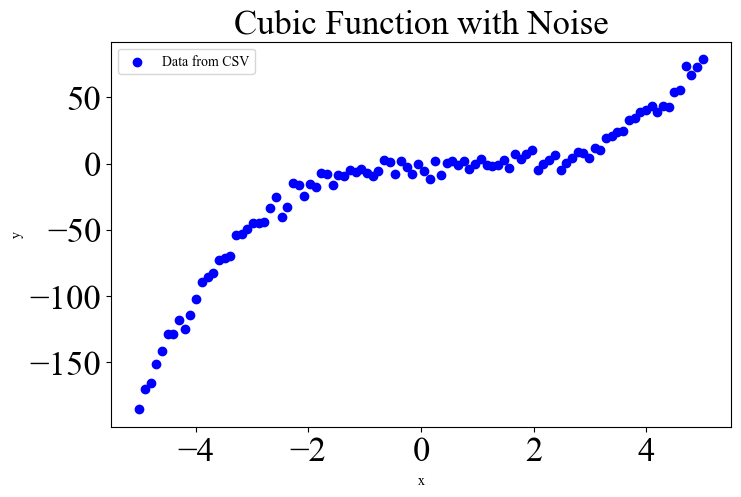

In [5]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt

# Create a figure with specified dimensions (8x5 inches)
plt.figure(figsize=(8, 5))

# Create a scatter plot using data from the CSV file
# x-axis: "x" column, y-axis: "y" column, with blue color and label
plt.scatter(df_csv["x"], df_csv["y"], label="Data from CSV", color="blue")

# Set label for x-axis
plt.xlabel("x")

# Set label for y-axis
plt.ylabel("y")

# Set plot title
plt.title("Cubic Function with Noise", fontsize=25)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)

# Display the legend to identify data series
plt.legend()

# Show the plot
plt.show()

In [6]:
# Save data in binary format (.npy)
# NumPy's native format for efficient storage
np.save("DATA/x.npy", x)
np.save("DATA/y.npy", y)

# Save data in text format (.txt)
# Human-readable format, but larger file size
np.savetxt("DATA/x.txt", x)
np.savetxt("DATA/y.txt", y)

Image dimensions (height, width, channels): (440, 640, 3)
Successfully saved RGB image data to text file.


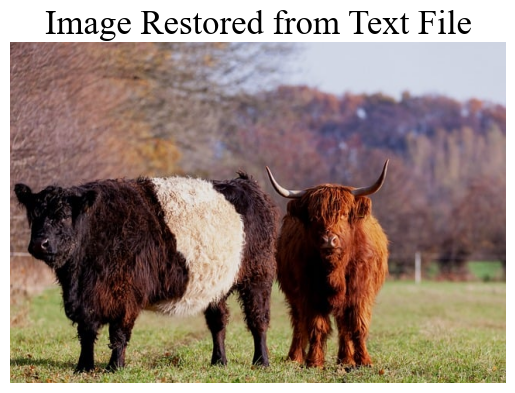

In [7]:
# ====== 1. Read and Convert Image to RGB Format ======
# Define path to the image file
image_path = 'DATA/wildlife-9653797_640.jpg'

# Read image using OpenCV (image is read in BGR - Blue Green Red format)
image = cv2.imread(image_path)
# Convert from BGR to RGB as matplotlib and other tools typically use RGB
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Print the dimensions of the converted image
# image_rgb.shape returns (height, width, number of color channels)
print("Image dimensions (height, width, channels):", image_rgb.shape)

# ====== 2. Convert Image from 3D to 2D Array for File Storage ======
# Reshape image from (height, width, 3) => (height*width, 3)
# Each row represents one pixel with 3 values: R, G, B
image_2d = image_rgb.reshape(-1, 3)

# ====== 3. Save Image Data to Text File ======
# Save the 2D array as a .txt file
# - '%d' formats each value as an integer
# - delimiter=',' separates values with commas
np.savetxt('DATA/image_rgb_values.txt', image_2d, fmt='%d', delimiter=',')

print("Successfully saved RGB image data to text file.")

# ====== 4. (Optional) Read Back and Verify Image ======

# Read data from the .txt file
# - delimiter=',' matches the save format
# - dtype=np.uint8 restores correct image data type
data = np.loadtxt('DATA/image_rgb_values.txt', delimiter=',', dtype=np.uint8)

# Convert 2D array back to 3D array with original image dimensions
image_restored = data.reshape(image_rgb.shape)

# Display the restored image for verification
plt.imshow(image_restored)
plt.axis('off')  # Hide axes
plt.title('Image Restored from Text File', fontsize=25)
plt.show()